# 单细胞数据整理 SOP

单细胞数据包含三大部分：

- 表达矩阵：细胞（行）与基因（列）的矩阵，记录了每个细胞中每个基因的表达量。
- 细胞元数据：每个细胞的相关信息，patient, sample, tissue, disease, treatment, cell_type, cell_type_subset
- 基因元数据：每个基因的相关信息, gene_name, ensembl_id, entrez_id

目录结构：

```tree
.
├── data
│   ├── cell_metadata/           # 细胞元数据文件，通常是CSV或TSV格式
│   ├── gene_metadata/           # 基因元数据文件, 通常是CSV或TSV格式
|   ├── rawdata/                 # 直接下载的原始数据文件，格式多样不统一，不过通常能从中提取出表达矩阵和元数据
│   ├── mtx                      # 原始表达矩阵文件，通常是稀疏矩阵格式
│   │   ├── sample1
│   │   │   ├── barcodes.tsv.gz
│   │   │   ├── features.tsv.gz
│   │   │   └── matrix.mtx.gz
│   │   ├── sample2
│   │   │   ├── barcodes.tsv.gz
│   │   │   ├── features.tsv.gz
│   │   │   └── matrix.mtx.gz
│   │   ├── ...
│   └── h5ad                     
│       └── adata.h5ad           # 预处理后的h5ad文件
├── doc/                         # 文献原文及其附件
├── src/
│   ├── ...                      # 自定义的数据处理脚本
│   └── sc_preprocess.ipynb      # 单细胞数据预处理的Jupyter Notebook
└── metadata.yaml                # 记录数据来源的元信息文件
```

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown


sc.settings.verbosity = 0
sc.set_figure_params(dpi=80, facecolor="white")

In [2]:
%load_ext autoreload
%autoreload 2
from parseGTF import read_gtf

## 整理数据

In [3]:
DATA_DIR = Path("../data")
DATA_DIR_MTX = DATA_DIR / "mtx"
DATA_DIR_CELL = DATA_DIR / "cell_metadata"
DATA_DIR_GENE = DATA_DIR / "gene_metadata"
DATA_DIR_H5AD = DATA_DIR / "h5ad"

DATA_DIR_H5AD.mkdir(exist_ok=True)

### 表达矩阵

In [25]:
sample_file_list = sorted(list(DATA_DIR_MTX.glob("*")))
sample_names = [_.name for _ in sample_file_list]


adata_dict = {}
for sn, sf in zip(sample_names, sample_file_list):
    adata = sc.read_10x_mtx(sf, var_names="gene_symbols", cache=True)
    adata.obs["sample"] = sn
    adata_dict[sn] = adata

In [26]:
adata = sc.concat(adata_dict, axis=0, label="sample", index_unique="-")

### 细胞元数据

In [6]:
obs = pd.read_csv(DATA_DIR_CELL / "GSE127465_human_cell_metadata_54773x25.tsv.gz", sep="\t")
obs.head()

,Patient,Tissue,Barcoding emulsion,Library,Barcode,Total counts,Percent counts from mitochondrial genes,Most likely LM22 cell type,Major cell type,Minor subset,...,y_NSCLC_and_blood_immune,used_in_NSCLC_immune,x_NSCLC_immune,y_NSCLC_immune,used_in_NSCLC_non_immune,x_NSCLC_non_immune,y_NSCLC_non_immune,used_in_blood,x_blood,y_blood
0,p1,blood,p1b,p1b1,bcCSBJ,25465.0,0.058904,T cells CD4 memory activated,bT cells,bCD4T1,...,-665.082369,False,NaN,NaN,False,NaN,NaN,True,1620.527869,-205.677730
1,p1,blood,p1b,p1b1,bcAVUP,7582.0,9.206014,Monocytes,bMonocytes,bMono2,...,-44.363755,False,NaN,NaN,False,NaN,NaN,True,1688.259525,-965.414268
2,p1,blood,p1b,p1b1,bcACUH,5022.0,5.575468,Monocytes,bpDC,bpDC,...,-366.652117,False,NaN,NaN,False,NaN,NaN,True,1537.052487,-719.481146
3,p1,blood,p1b,p1b1,bcDLRE,3694.0,6.361668,T cells CD4 memory resting,bT cells,bCD4T1,...,-1450.307801,False,NaN,NaN,False,NaN,NaN,True,1590.280870,-200.568512
4,p1,blood,p1b,p1b1,bcESSY,2945.0,6.213922,NK cells resting,bNK cells,bNK cells,...,-739.119340,False,NaN,NaN,False,NaN,NaN,True,1344.771262,228.322604


**关键列**

| 列名 | 描述 |
| --- | --- |
| `cell_id` | 细胞ID，格式为 Barcode-Library |
| `Barcode` | 细胞条形码 |
| `Library` | 文库ID |
| `Patient` | 患者ID |
| `Tissue` | 组织来源 |
| `Major cell type` | 主要细胞类型 |
| `Minor subset` | 细分亚细胞类型 |
| `used_in_NSCLC_all_cells` | 是否用于NSCLC所有细胞分析 |
| `x_NSCLC_all_cells` | SPRING Plot 坐标 x 轴 |
| `y_NSCLC_all_cells` | SPRING Plot 坐标 y 轴 |
| `used_in_NSCLC_immnue` | 是否用于NSCLC免疫细胞分析 |
| `x_NSCLC_immune` | SPRING Plot 坐标 x 轴 |
| `y_NSCLC_immune` | SPRING Plot 坐标 y 轴 |
| `used_in_NSCLC_non_immune` | 是否用于NSCLC非免疫细胞分析 |
| `x_NSCLC_non_immune` | SPRING Plot 坐标 x 轴 |
| `y_NSCLC_non_immune` | SPRING Plot 坐标 y 轴



In [7]:
treatment = {"p1": "", "p2": "Chemo and XRT", "p3": "", "P4": ""}

obs["cell_id"] = obs["Barcode"].str.cat(obs["Library"], sep="-")
obs["patient"] = obs["Patient"]
obs["sample"] = obs["Library"]
obs["tissue"] = obs["Tissue"]
obs["disease"] = "Non Small Cell Lung Cancer"
obs["treatment"] = obs["Patient"].map(treatment)
obs["cell_type"] = obs["Major cell type"]
obs["cell_type_subset"] = obs["Minor subset"]
obs = obs.loc[
    :, ["cell_id", "patient", "sample", "tissue", "disease", "treatment", "cell_type", "cell_type_subset"]
]
obs.index = obs["cell_id"]

obs.head()

,cell_id,patient,sample,tissue,disease,treatment,cell_type,cell_type_subset
cell_id,,,,,,,,
bcCSBJ-p1b1,bcCSBJ-p1b1,p1,p1b1,blood,Non Small Cell Lung Cancer,,bT cells,bCD4T1
bcAVUP-p1b1,bcAVUP-p1b1,p1,p1b1,blood,Non Small Cell Lung Cancer,,bMonocytes,bMono2
bcACUH-p1b1,bcACUH-p1b1,p1,p1b1,blood,Non Small Cell Lung Cancer,,bpDC,bpDC
bcDLRE-p1b1,bcDLRE-p1b1,p1,p1b1,blood,Non Small Cell Lung Cancer,,bT cells,bCD4T1
bcESSY-p1b1,bcESSY-p1b1,p1,p1b1,blood,Non Small Cell Lung Cancer,,bNK cells,bNK cells


### 基因元数据

In [22]:
var = read_gtf(DATA_DIR_GENE / "Homo_sapiens.GRCh38.81.gene.gtf.gz")
var.head()

/media/jmbio/HDDmatrix0/houzl/database/scRNA/2019Zilionis_Immunity_NSCLC/src/parseGTF.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if gtf['attribute'].str.contains(r'gene_type "([^"]+)"').any():
/media/jmbio/HDDmatrix0/houzl/database/scRNA/2019Zilionis_Immunity_NSCLC/src/parseGTF.py:28: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  elif gtf['attribute'].str.contains(r'gene_biotype "([^"]+)"').any():


,seqname,source,feature,start,end,score,strand,frame,gene_id,gene_name,gene_type,transcript_id,transcript_name,transcript_type,exon_number,exon_id,attribute
0,1,havana,gene,11869,14409,.,+,.,ENSG00000223972,DDX11L1,transcribed_unprocessed_pseudogene,NaN,NaN,NaN,NaN,NaN,"gene_id ""ENSG00000223972""; gene_version ""5""; g..."
1,1,havana,gene,14404,29570,.,-,.,ENSG00000227232,WASH7P,unprocessed_pseudogene,NaN,NaN,NaN,NaN,NaN,"gene_id ""ENSG00000227232""; gene_version ""5""; g..."
2,1,ensembl,gene,17369,17436,.,-,.,ENSG00000278267,MIR6859-1,miRNA,NaN,NaN,NaN,NaN,NaN,"gene_id ""ENSG00000278267""; gene_version ""1""; g..."
3,1,havana,gene,29554,31109,.,+,.,ENSG00000243485,RP11-34P13.3,lincRNA,NaN,NaN,NaN,NaN,NaN,"gene_id ""ENSG00000243485""; gene_version ""3""; g..."
4,1,ensembl,gene,30366,30503,.,+,.,ENSG00000274890,MIR1302-2,miRNA,NaN,NaN,NaN,NaN,NaN,"gene_id ""ENSG00000274890""; gene_version ""1""; g..."


In [24]:
var_columns = ["seqname", "start", "end", "strand", "gene_id", "gene_name", "gene_type"]
var_rows = (var["feature"] == "gene") & (var["gene_name"].isin(adata.var_names))

var = (
    var.loc[var_rows, var_columns]
    .drop_duplicates(subset=["gene_name"], keep="first")
    .apply(lambda x: x.astype(str))
)
var.index = var["gene_name"]
var.head()

,seqname,start,end,strand,gene_id,gene_name,gene_type
gene_name,,,,,,,
MIR6859-1,1,17369,17436,-,ENSG00000278267,MIR6859-1,miRNA
MIR1302-2,1,30366,30503,+,ENSG00000274890,MIR1302-2,miRNA
FAM138A,1,34554,36081,-,ENSG00000237613,FAM138A,lincRNA
OR4F5,1,69091,70008,+,ENSG00000186092,OR4F5,protein_coding
RNU6-1100P,1,157784,157887,-,ENSG00000222623,RNU6-1100P,snRNA


### 组装三部分成 Anndata

In [27]:
adata = adata[obs["cell_id"], :].copy()

In [28]:
adata.obs = obs

In [29]:
adata.var = adata.var.merge(var, left_index=True, right_index=True, how="left")

In [30]:
adata.write_h5ad(DATA_DIR_H5AD / "adata.h5ad")
adata

AnnData object with n_obs × n_vars = 54773 × 41861
    obs: 'cell_id', 'patient', 'sample', 'tissue', 'disease', 'treatment', 'cell_type', 'cell_type_subset'
    var: 'seqname', 'start', 'end', 'strand', 'gene_id', 'gene_name', 'gene_type'

## 统一预处理



单细胞数据预处理是指对单细胞测序数据进行清洗、过滤、归一化等步骤，以便后续的分析和解读。以下是一些常见的单细胞数据预处理步骤：

- 质量控制（Quality Control）：评估每个细胞的质量指标，例如总表达量、基因数、线粒体基因比例等。
- (可选)过滤（Filtering）：根据一定的标准过滤掉不符合要求的细胞和基因，例如表达量过低的基因或细胞。
- 归一化（Normalization）：对数据进行归一化处理，以消除技术变异。
- 合并（Integration）：如果有多个样本，需要将它们合并在一起进行分析。
- 降维（Dimensionality Reduction）：使用PCA、t-SNE或UMAP等方法将高维数据降维，以便可视化和后续分析。
- 聚类 (Clustering)：将细胞分成不同的群体，以便识别不同的细胞类型或状态。
- 注释 (Annotation)：根据已知的标记基因或参考数据集对细胞进行注释，确定它们的类型或状态。

> [!NOTE]
> **过滤**步骤是可选的，有时候从文章的附件中拿到的细胞已经经过了过滤处理，因此在预处理过程中不需要再次进行过滤。

## 质量控制

In [31]:
rbc_genes = [
    "HBA1",
    "HBA2",
    "HBB",
    "HBD",
    "HBE1",
    "HBG1",
    "HBG2",
    "HBZ",
    "HBM",
    "HBQ1"
]

In [32]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.isin(rbc_genes)

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=False)

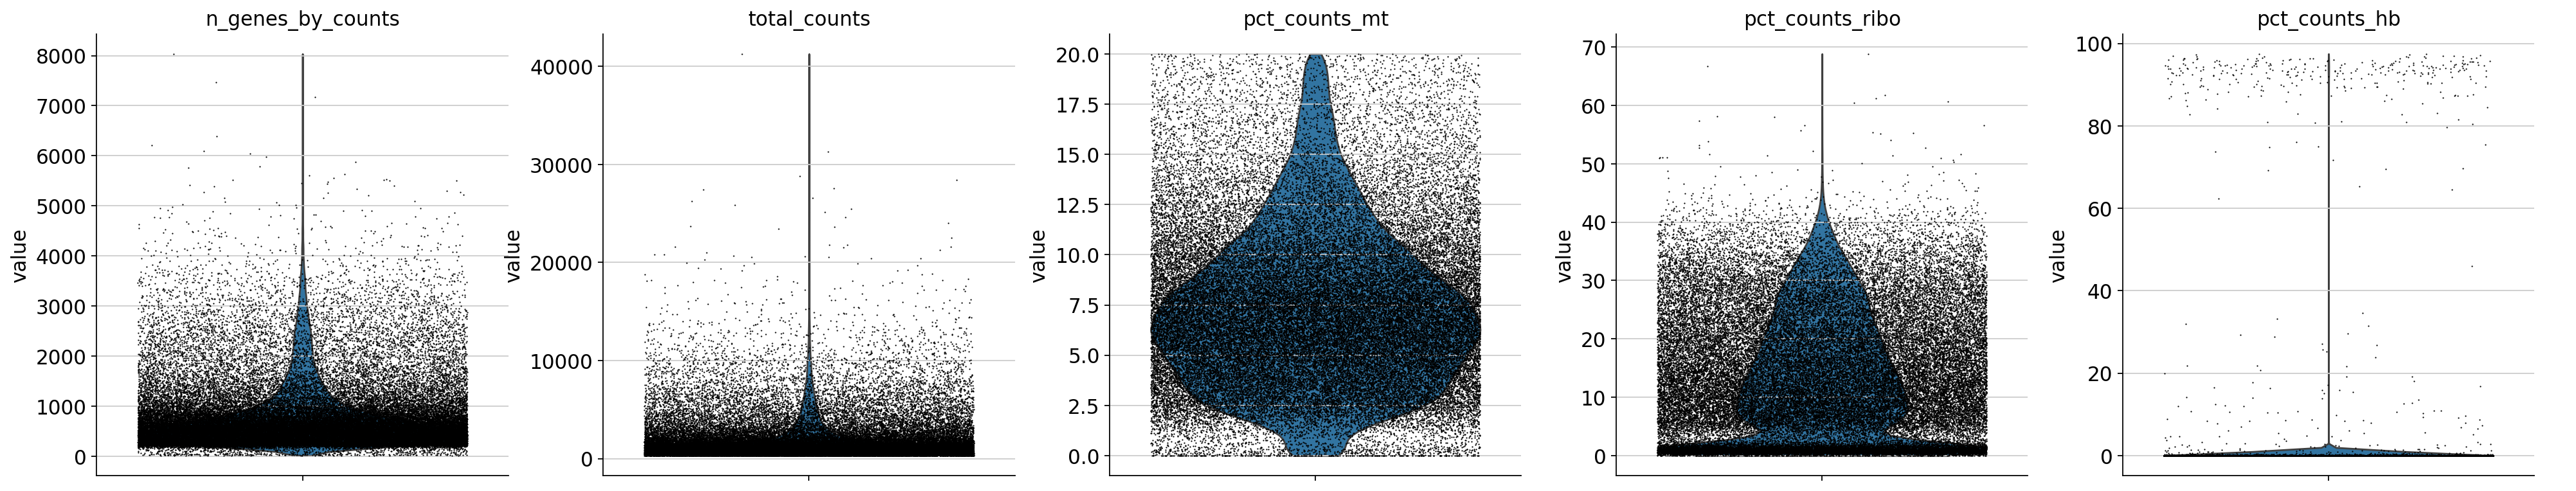

In [33]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

## 归一化

In [35]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

## 降维

### Feature Selection

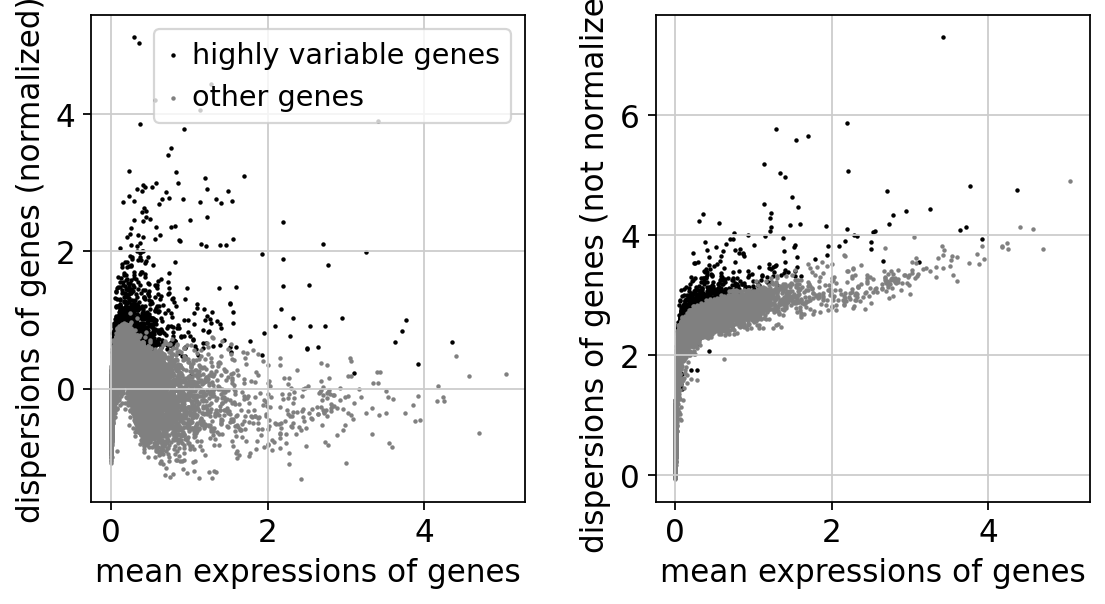

In [37]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata)

### PCA

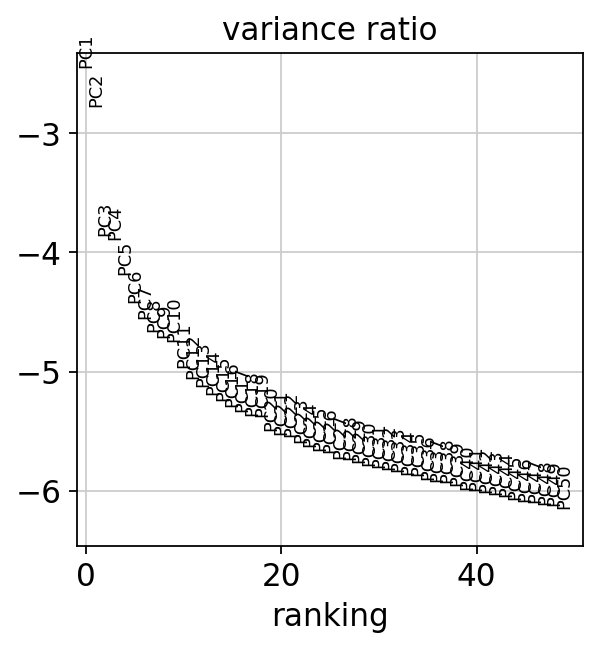

In [38]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

### UMAP

In [40]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

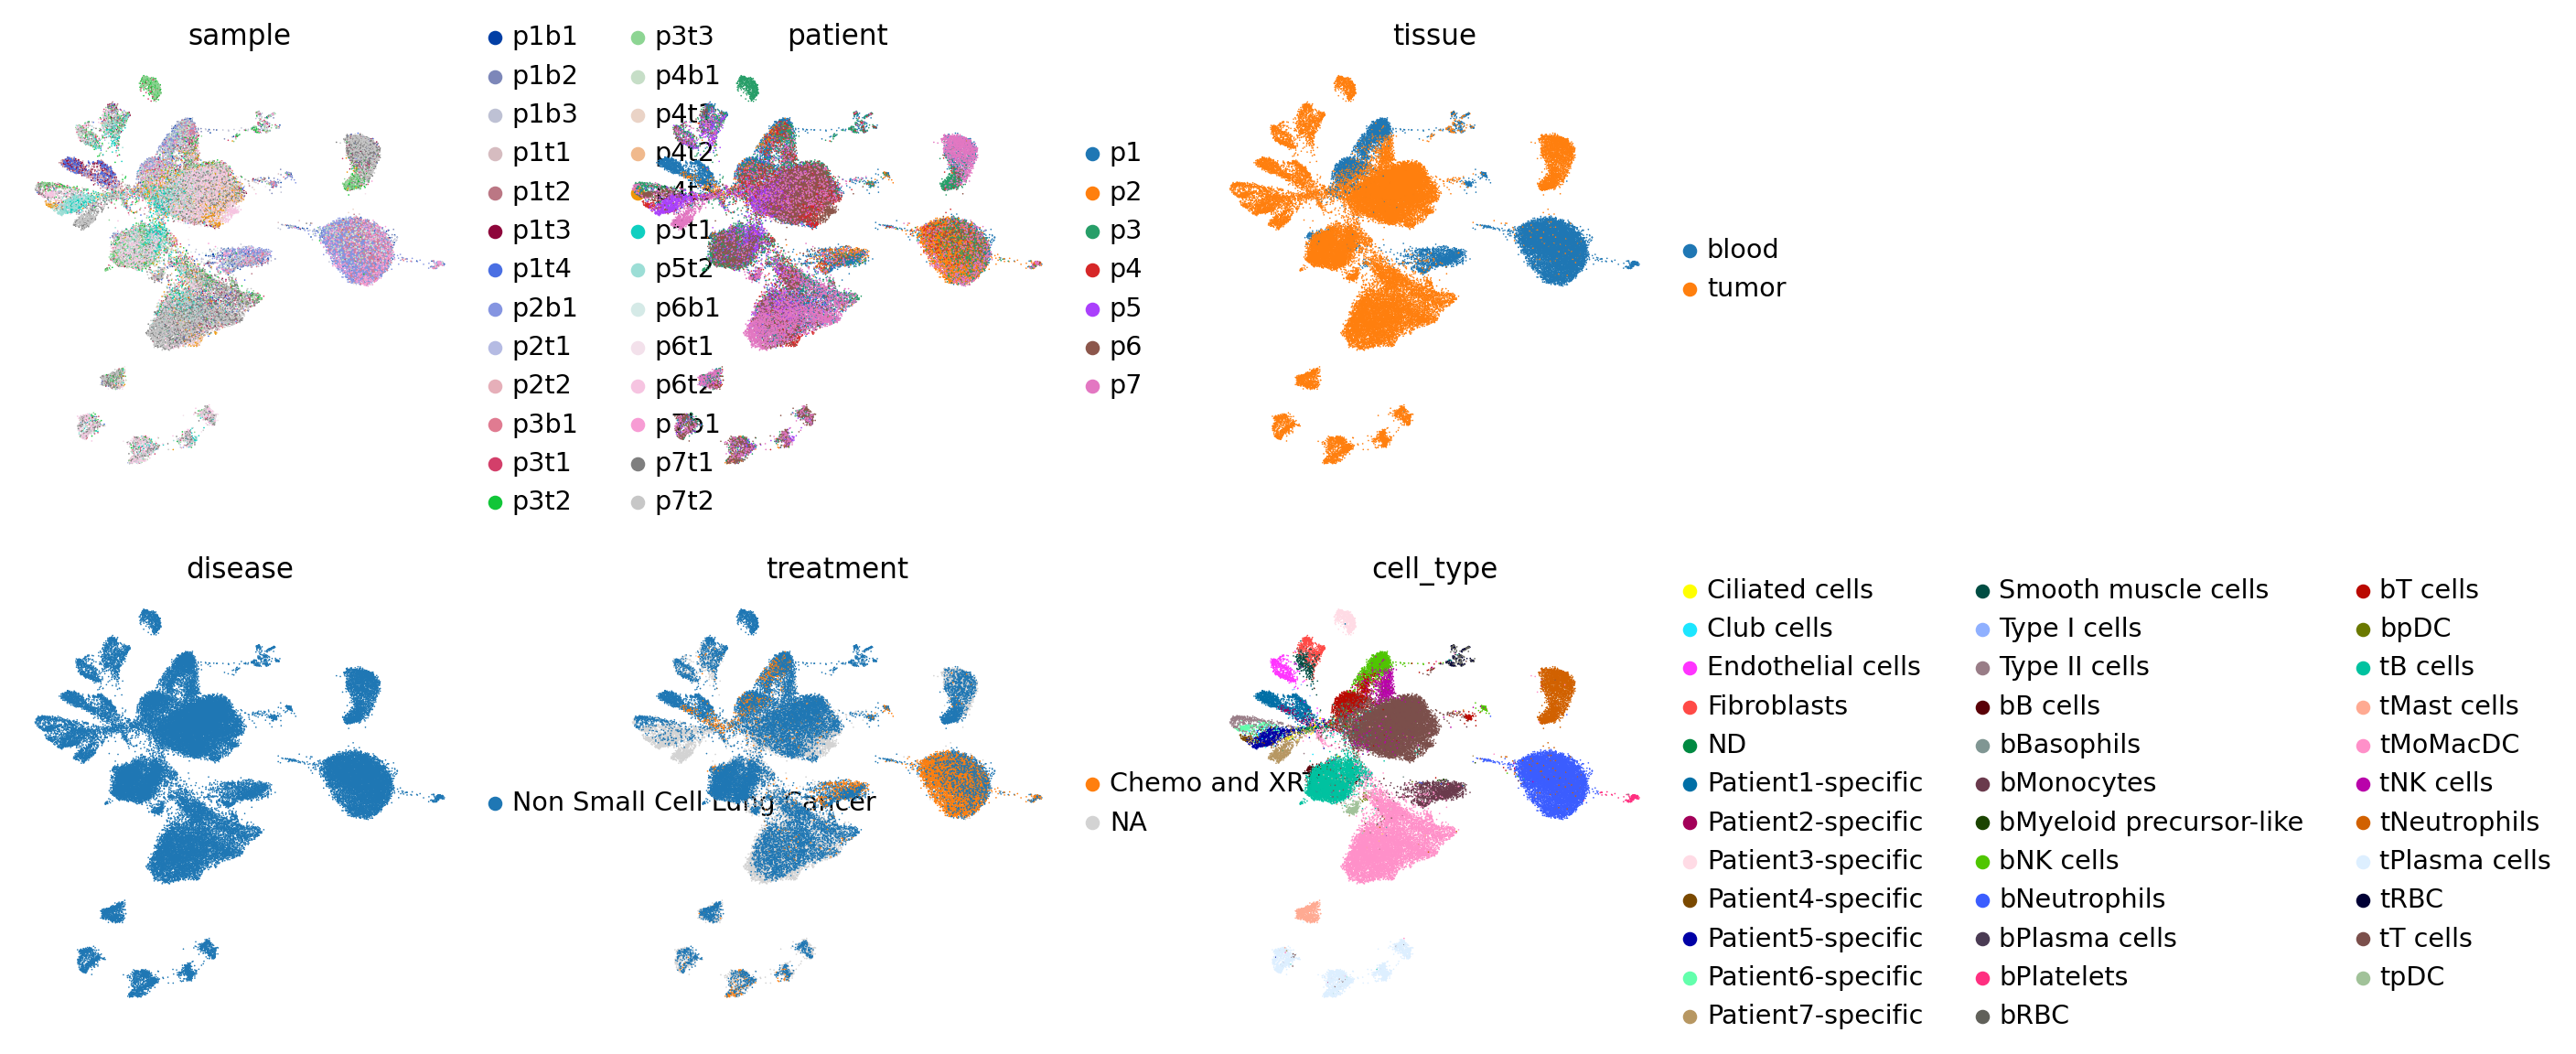

In [44]:
sc.pl.umap(
    adata,
    color=["sample", "patient", "tissue", "disease", "treatment", "cell_type"],
    frameon=False,
    ncols=3
)

### 聚类

In [45]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

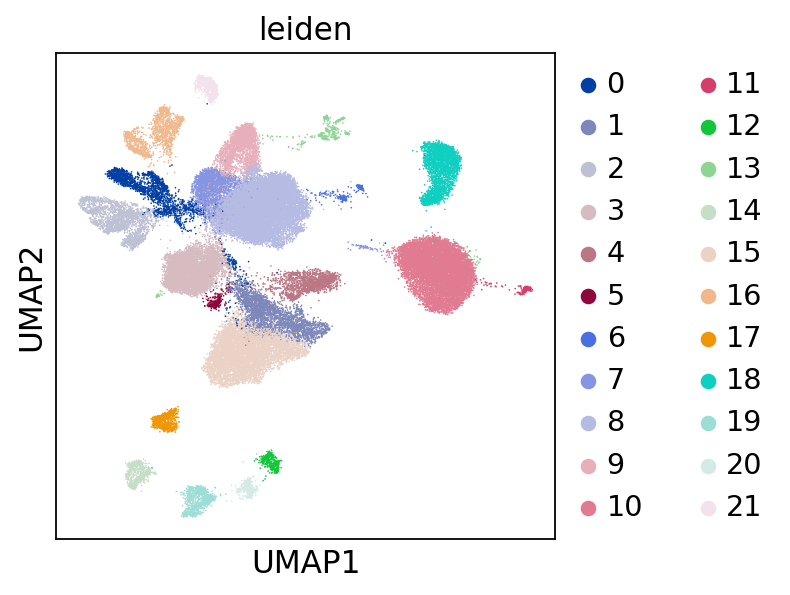

In [46]:
sc.pl.umap(adata, color=["leiden"])

In [47]:
adata.write_h5ad(DATA_DIR_H5AD / "adata.h5ad")